# TCGA Lung Cancer: ML Classification of LUAD vs LUSC

In the R analysis, we saw that LUAD and LUSC separate cleanly on PCA and have hundreds of differentially expressed genes. Here we ask: **can a simple machine learning model learn to classify cancer type from gene expression alone?**

This is a natural follow-up — differential expression tells us *which* genes differ, but a classifier tells us *how well* the combined signal discriminates, and which genes carry the most predictive weight.


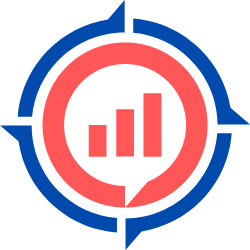

In [1]:
%load_ext gofigr

configure(
    analysis=FindByName("TCGA Lung Cancer Analysis (LUAD + LUSC)", create=True),
)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gofigr.reproducible import reproducible, DropdownParam, StaticParam

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.preprocessing import StandardScaler

## Load data

We read the expression matrix and clinical metadata exported by the R analysis as parquet files. The expression matrix is log2(TPM+1) for primary tumor samples, with genes as columns.

These files are produced by `download_tcga.R`. If you'd rather skip the R download step, pre-built copies are available at:

- https://cdn.gofigr.io/data/expr_tumor.parquet
- https://cdn.gofigr.io/data/clinical_tumor.parquet


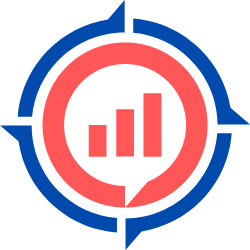


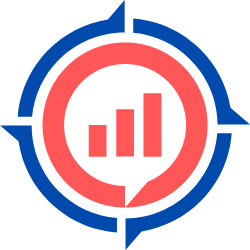

Samples: 1051 | Genes: 1234
LUAD: 540 | LUSC: 511


In [3]:
expr = gf.read_parquet("../data/expr_tumor.parquet")
clinical = gf.read_parquet("../data/clinical_tumor.parquet")

X = expr.values
y = (clinical["cohort"] == "LUSC").astype(int).values  # 1 = LUSC, 0 = LUAD
gene_names = expr.columns.tolist()

# Build a combined frame for the reproducible figure
clf_df = clinical.copy()
clf_df["stage_simple"] = clf_df["stage"].str.extract(r"Stage (I+V?|I)")[0]

print(f"Samples: {X.shape[0]} | Genes: {X.shape[1]}")
print(f"LUAD: {(y == 0).sum()} | LUSC: {(y == 1).sum()}")

## Figure 1: Logistic Regression — Top Predictive Genes

We train an L1-regularized (Lasso) logistic regression using 5-fold cross-validation. L1 regularization drives most coefficients to zero, selecting the genes that matter most for classification. The surviving non-zero coefficients are the model's "feature importance" — positive coefficients push toward LUSC, negative toward LUAD.

We expect the top features to overlap with the differentially expressed genes from the R volcano plot: keratins and TP63 for LUSC, surfactant proteins and NKX2-1 for LUAD.

Non-zero coefficients: 49 / 1234 genes


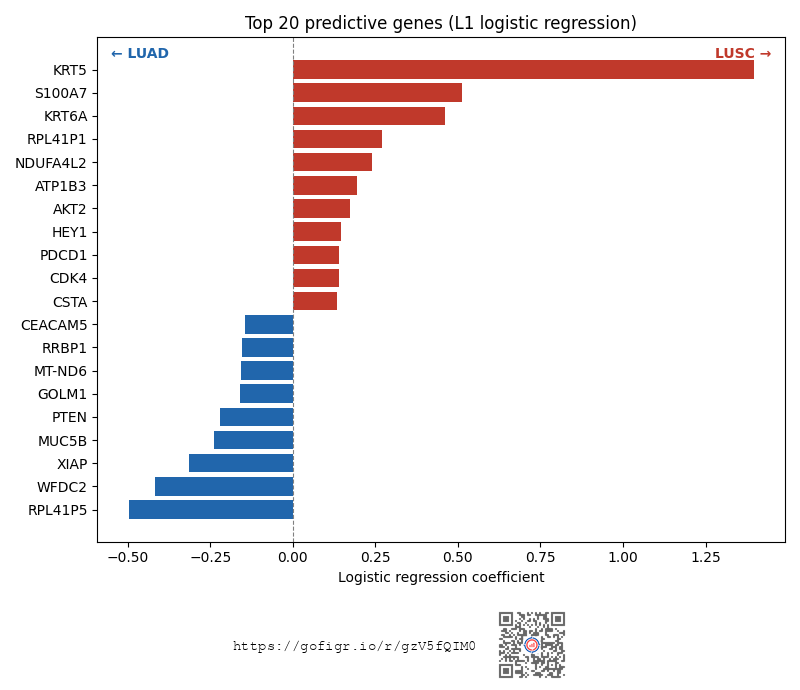


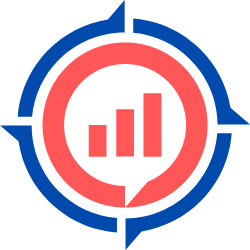
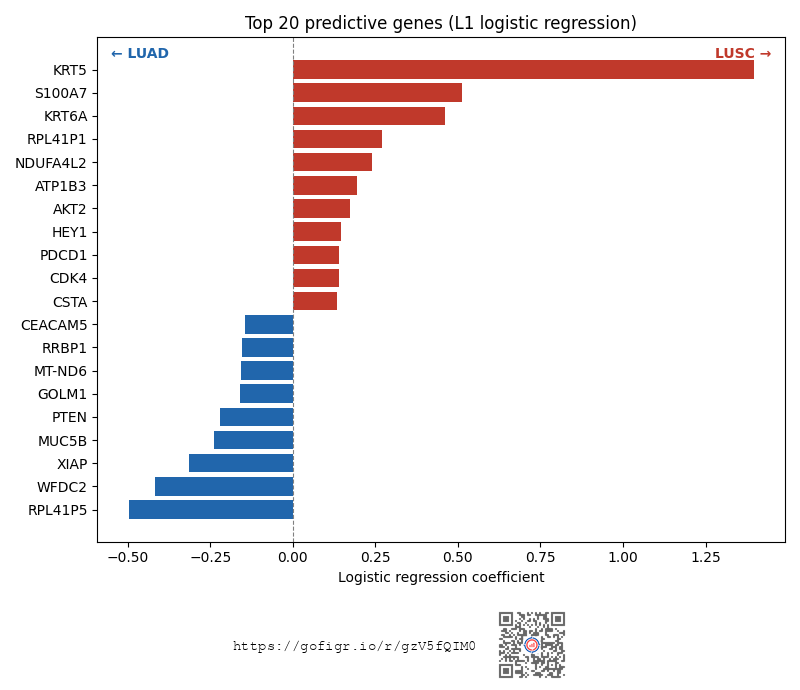
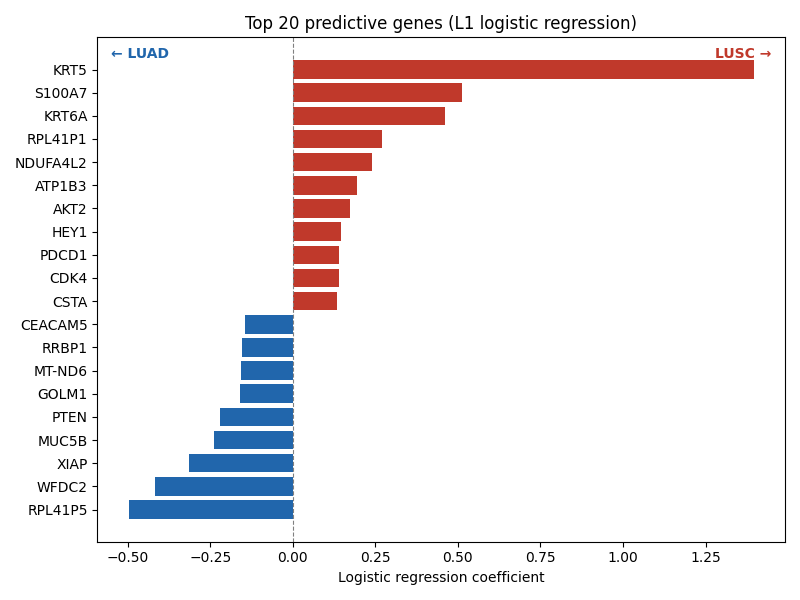
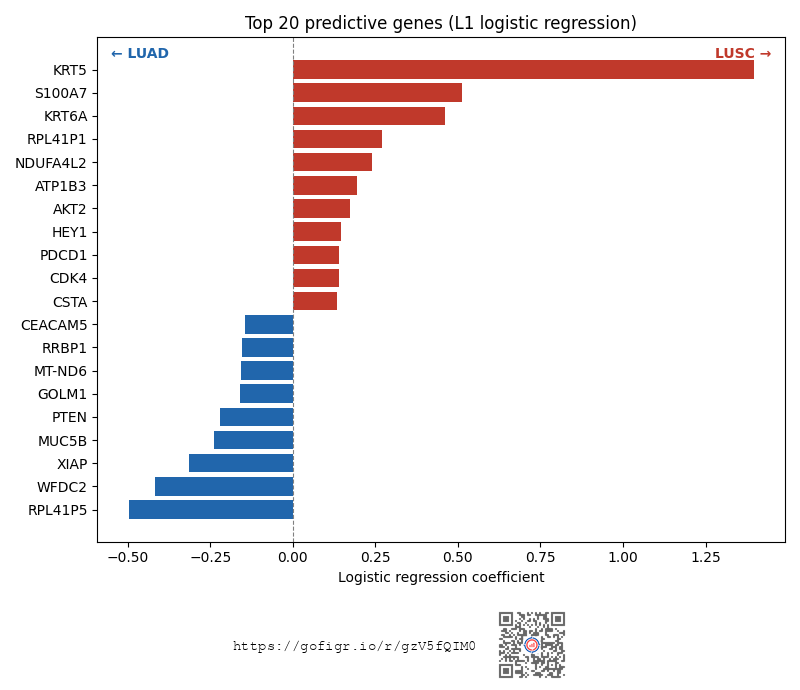
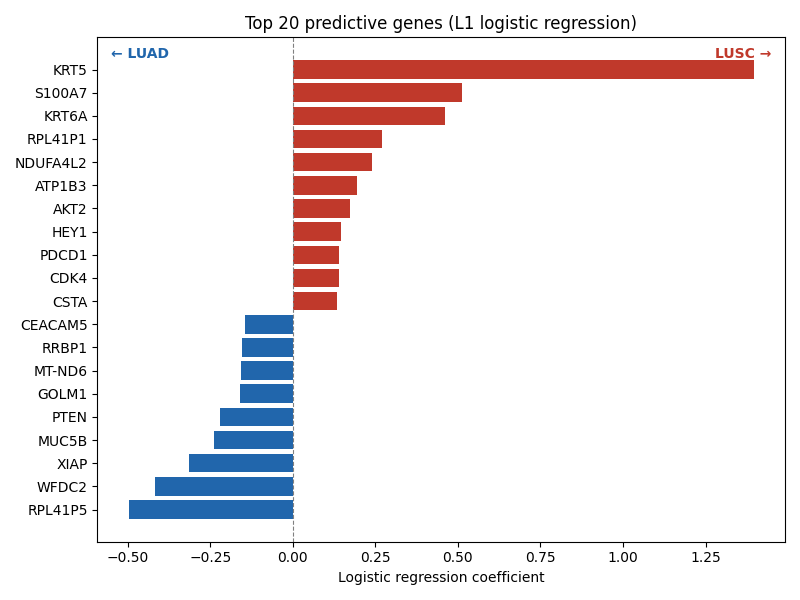

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression(l1_ratio=1, C=0.1, solver="liblinear", random_state=42)
model.fit(X_scaled, y)

# Extract non-zero coefficients
coefs = pd.Series(model.coef_[0], index=gene_names)
nonzero = coefs[coefs != 0].sort_values()

print(f"Non-zero coefficients: {len(nonzero)} / {len(gene_names)} genes")

# Plot top 20 by absolute magnitude
top_n = 20
top_genes = nonzero.reindex(nonzero.abs().nlargest(top_n).index).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#2166ac" if v < 0 else "#c0392b" for v in top_genes.values]
ax.barh(top_genes.index, top_genes.values, color=colors)
ax.set_xlabel("Logistic regression coefficient")
ax.set_title(f"Top {top_n} predictive genes (L1 logistic regression)")
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")

# Add direction labels
ax.text(0.02, 0.98, "← LUAD", transform=ax.transAxes, va="top", ha="left",
        fontsize=10, color="#2166ac", fontweight="bold")
ax.text(0.98, 0.98, "LUSC →", transform=ax.transAxes, va="top", ha="right",
        fontsize=10, color="#c0392b", fontweight="bold")

plt.tight_layout()
plt.show()

## Figure 2: ROC Curve (interactive)

How well does the classifier discriminate? We use 5-fold stratified cross-validation to get out-of-fold predicted probabilities, then plot the ROC curve.

This plot is wrapped with `@reproducible` so viewers can re-stratify by clinical subgroups (gender, stage) directly in the GoFigr portal — does the classifier perform equally well in all subpopulations?

In [5]:
# Run the cross-validation once, here in the host notebook
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_proba = cross_val_predict(
    LogisticRegression(l1_ratio=1, C=0.1, solver="liblinear", random_state=42),
    X_scaled, y, cv=cv, method="predict_proba",
)[:, 1]


@reproducible(
    packages={
        "np": "numpy",
        "plt": "matplotlib.pyplot",
        "sklearn": "sklearn"
    },
    interactive=True
)
def plot_roc(
    y_true=StaticParam(y),
    y_score=StaticParam(y_proba),
    clinical_df=StaticParam(clf_df),
    gender: str = DropdownParam("All", choices=["All", "male", "female"]),
    stage: str = DropdownParam("All", choices=["All", "I", "II", "III", "IV"])
):
    from sklearn.metrics import roc_curve
    from sklearn.metrics import auc
    mask = np.ones(len(clinical_df), dtype=bool)
    if gender != "All":
        mask &= (clinical_df["gender"].values == gender)
    if stage != "All":
        mask &= (clinical_df["stage_simple"].values == stage)

    y_sub = np.asarray(y_true)[mask]
    p_sub = np.asarray(y_score)[mask]

    if len(np.unique(y_sub)) < 2:
        print(f"Insufficient data: n={len(y_sub)}, classes={np.unique(y_sub)}")
        return

    fpr, tpr, _ = roc_curve(y_sub, p_sub)
    roc_auc = auc(fpr, tpr)

    subtitle_parts = [f"n={len(y_sub)}"]
    if gender != "All":
        subtitle_parts.append(gender)
    if stage != "All":
        subtitle_parts.append(f"Stage {stage}")
    subtitle = " | ".join(subtitle_parts)

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(fpr, tpr, color="#c0392b", lw=2, label=f"AUC = {roc_auc:.3f}")
    ax.plot([0, 1], [0, 1], color="grey", lw=1, linestyle="--", label="Random")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(f"ROC: LUAD vs LUSC ({subtitle})")
    ax.legend(loc="lower right", fontsize=12)
    ax.set_aspect("equal")
    plt.tight_layout()
    publish(fig, target="ROC: LUAD vs LUSC classification")
    
plot_roc()

<gofigr.reproducible.ReproducibleWidget._get_widget_class.<locals>._ReproducibleWidgetImpl object at 0x16f7cfb90>

Output()

## Figure 3: ML Features vs Differential Expression

The ultimate sanity check: do the genes the ML model selects as most predictive match the genes that are most differentially expressed? We compare the top 20 ML coefficients (by absolute value) against the top 20 DE genes (by absolute log2 fold-change from the R analysis).

Strong overlap confirms that the classifier is learning real biology, not overfitting to noise.

Top 50 ML genes: 49
Top 50 DE genes: 50
Overlap: 9 (18%)


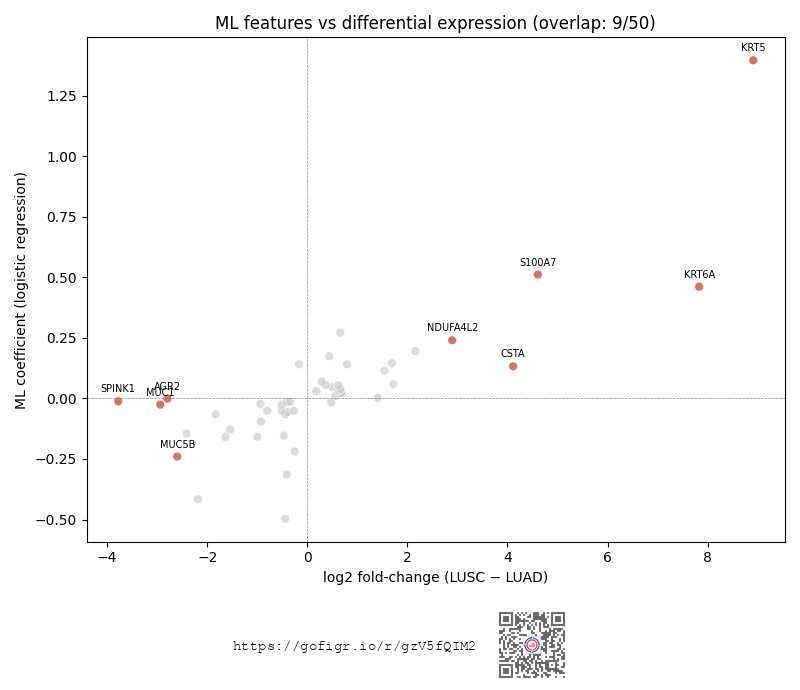


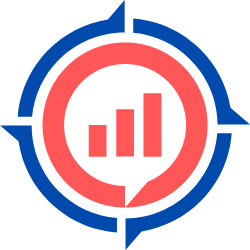
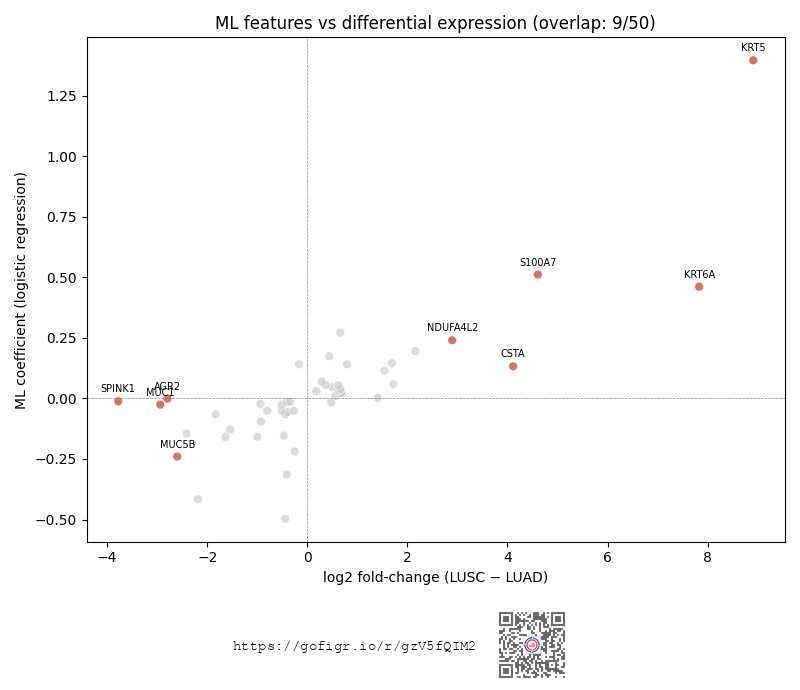
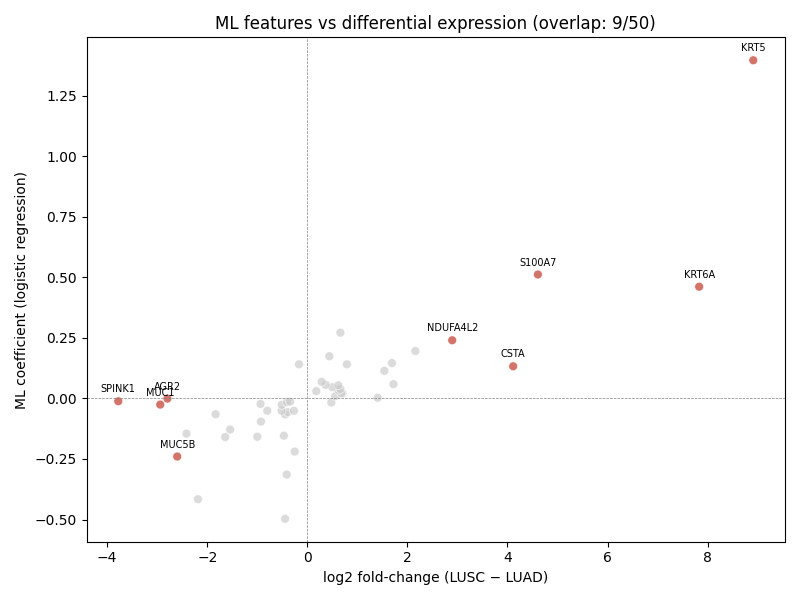
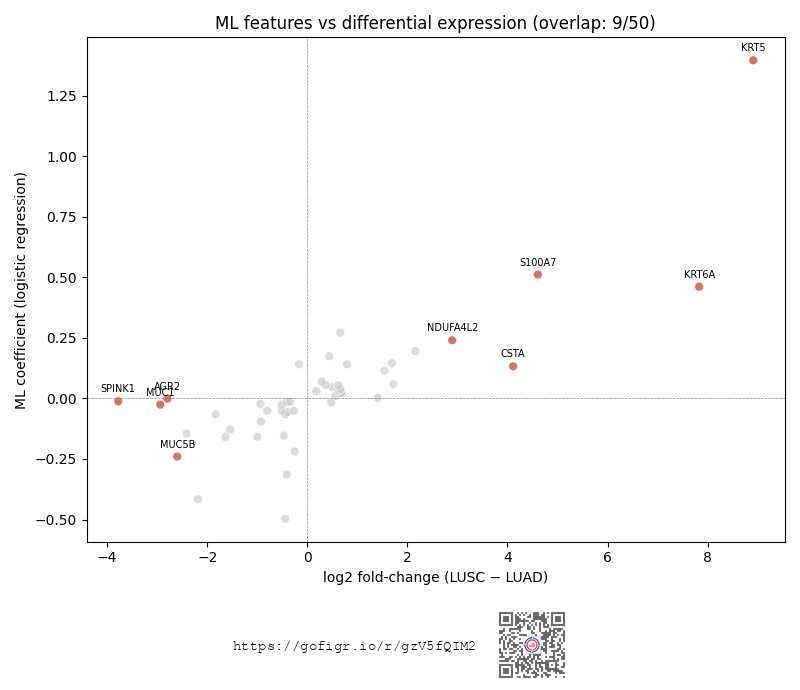
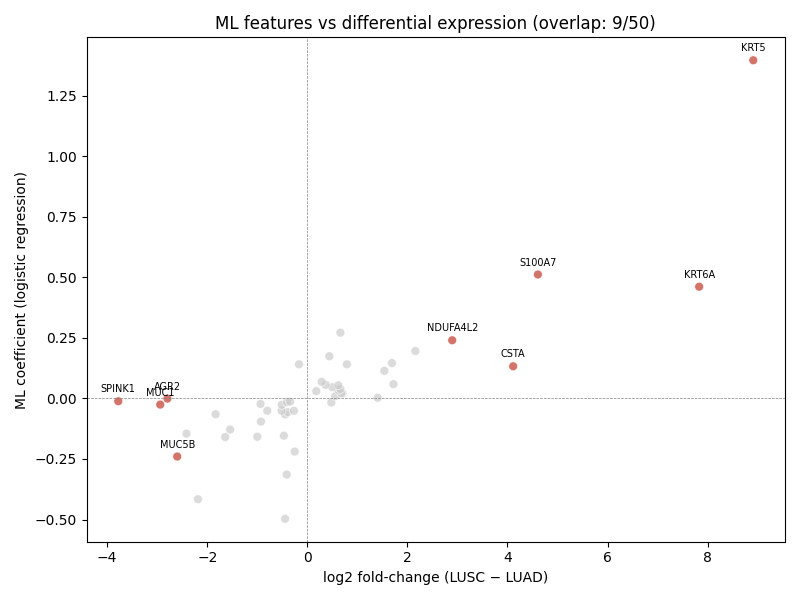

In [6]:
# Compute DE fold-changes (same approach as the R volcano plot)
luad_mask = y == 0
lusc_mask = y == 1
log2fc = X[lusc_mask].mean(axis=0) - X[luad_mask].mean(axis=0)
fc_series = pd.Series(log2fc, index=gene_names)

# Top 50 by each method
n_compare = 50
top_ml = set(nonzero.abs().nlargest(n_compare).index)
top_de = set(fc_series.abs().nlargest(n_compare).index)
overlap = top_ml & top_de

print(f"Top {n_compare} ML genes: {len(top_ml)}")
print(f"Top {n_compare} DE genes: {len(top_de)}")
print(f"Overlap: {len(overlap)} ({100*len(overlap)/n_compare:.0f}%)")

# Scatter: ML coefficient vs DE fold-change for all non-zero ML genes
plot_df = pd.DataFrame({
    "log2fc": fc_series[nonzero.index],
    "ml_coef": nonzero
})
plot_df["in_top_de"] = plot_df.index.isin(top_de)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(plot_df["log2fc"], plot_df["ml_coef"],
           c=plot_df["in_top_de"].map({True: "#c0392b", False: "#cccccc"}),
           s=40, alpha=0.7, edgecolors="white", linewidth=0.5)

# Label the overlap genes
for gene in list(overlap)[:15]:  # label up to 15 to avoid crowding
    row = plot_df.loc[gene]
    ax.annotate(gene, (row["log2fc"], row["ml_coef"]),
                fontsize=7, ha="center", va="bottom",
                xytext=(0, 5), textcoords="offset points")

ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
ax.axvline(0, color="grey", linewidth=0.5, linestyle="--")
ax.set_xlabel("log2 fold-change (LUSC − LUAD)")
ax.set_ylabel("ML coefficient (logistic regression)")
ax.set_title(f"ML features vs differential expression (overlap: {len(overlap)}/{n_compare})")
plt.tight_layout()
plt.show()